## Solving Laplace’s Equation in 2D

We consider Laplace’s equation in cartesian coordinates in two dimensions,

$$
V_{xx} + V_{yy} = 0.
$$

To approximate the solution numerically, we use the **relaxation method**, which is based on a finite-difference approximation to the Laplacian. On a grid with spacing $ h $, this leads to the update rule

$$
V^{(n+1)}(x,y)
=
\frac{1}{4}
\left[
V^{(n)}(x-h,y)
+
V^{(n)}(x+h,y)
+
V^{(n)}(x,y-h)
+
V^{(n)}(x,y+h)
\right]
$$

This means that, at each step, every interior point is replaced by the average of its four nearest neighbours.

We apply this method on the rectangular domain $ [0,2]\times[0,1] $, with boundary conditions

$$
V(0,y) = V(2,y) = 1
$$

$$
V(x,0) = V(x,1) = -1
$$

Starting from an initial grid that satisfies these boundary values, we iteratively update the interior points until the solution converges to a discrete approximation of the harmonic function determined by the boundary conditions.

Maximum discrete Laplace residual: 5.2571067499229684e-09


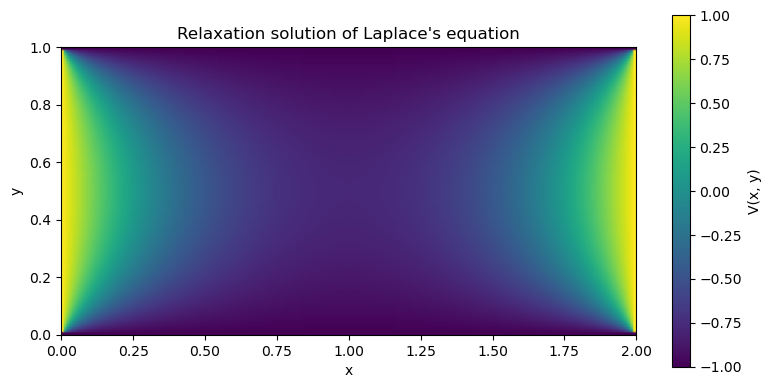

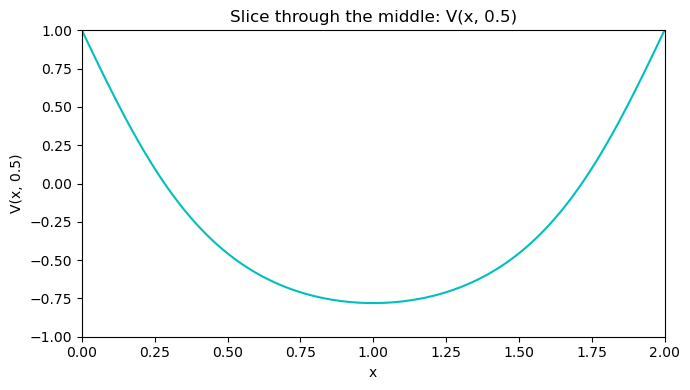

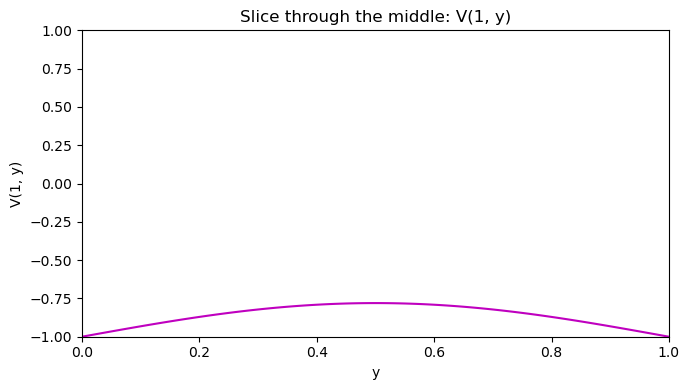

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# Create the rectangular grid and impose the boundary conditions
def initialize_grid(nx = 201, ny = 101):
    x = np.linspace(0, 2, nx)
    y = np.linspace(0, 1, ny)

    V = np.zeros((ny, nx))

    # Boundary conditions
    V[:, 0] = 1      # V(0, y) = 1
    V[:, -1] = 1     # V(2, y) = 1
    V[0, :] = -1     # V(x, 0) = -1
    V[-1, :] = -1    # V(x, 1) = -1

    return x, y, V


# Solve Laplace's equation using the relaxation method
def solve_laplace_relaxation(V, iterations = 40000):
    V = V.copy()

    # Replace each interior point by the average of its four neighbours
    for _ in range(iterations):
        V[1:-1, 1:-1] = 0.25 * (
            V[1:-1, :-2]    # left neighbours
            + V[1:-1, 2:]   # right neighbours
            + V[:-2, 1:-1]  # lower neighbours
            + V[2:, 1:-1]   # upper neighbours
        )

    return V


# Check how closely the grid satisfies the discrete Laplace equation
def laplace_residual(V):
    residual = (
        V[1:-1, :-2]
        + V[1:-1, 2:]
        + V[:-2, 1:-1]
        + V[2:, 1:-1]
        - 4 * V[1:-1, 1:-1]
    )

    return np.max(np.abs(residual))


# Plot the full 2D solution as a smooth colour map
def plot_solution_map(x, y, V):
    fig, ax = plt.subplots(figsize = (8, 4))

    im = ax.imshow(
        V,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin = "lower",
        vmin = -1,
        vmax = 1,
        aspect = "equal"
    )

    cbar = fig.colorbar(im, ax = ax)
    cbar.ax.set_ylabel("V(x, y)")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Relaxation solution of Laplace's equation")

    plt.tight_layout()
    plt.show()


# Plot V(x, 0.5)
def plot_x_slice(x, V):
    mid_y_index = V.shape[0] // 2

    fig, ax = plt.subplots(figsize = (7, 4))

    ax.plot(x, V[mid_y_index, :], 'c-')

    ax.set_xlabel("x")
    ax.set_ylabel("V(x, 0.5)")
    ax.set_title("Slice through the middle: V(x, 0.5)")
    ax.set_xlim(0, 2)
    ax.set_ylim(-1, 1)

    plt.tight_layout()
    plt.show()


# Plot V(1, y)
def plot_y_slice(y, V):
    mid_x_index = V.shape[1] // 2

    fig, ax = plt.subplots(figsize = (7, 4))

    ax.plot(y, V[:, mid_x_index], 'm-')

    ax.set_xlabel("y")
    ax.set_ylabel("V(1, y)")
    ax.set_title("Slice through the middle: V(1, y)")
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 1)

    plt.tight_layout()
    plt.show()


# Create the grid and initial guess
x, y, V_initial = initialize_grid(nx = 201, ny = 101)

# Solve the boundary value problem
V = solve_laplace_relaxation(V_initial, iterations = 40000)

# Print convergence check
print("Maximum discrete Laplace residual:", laplace_residual(V))

# Plot results
plot_solution_map(x, y, V)
plot_x_slice(x, V)
plot_y_slice(y, V)